# Chapter 14 - Orbit Correction

While operating an accelerator, the beam orbit is measured at selected locations with beam position monitors (BPMs). The design orbit is often chosen so the ideal BPM readings are zero, but a real machine may instead use a measured reference orbit, often called a golden orbit. Orbit correction changes the beam trajectory so the BPM readings approach the desired values.

In this SciBmad notebook, a BPM is represented as a zero-length `Marker`: it gives us a named location where the orbit can be read. A corrector is represented as a `Kicker`: it can apply a small transverse kick and therefore changes the downstream orbit.


In [16]:
using SciBmad
using CairoMakie
using LinearAlgebra
using Statistics
using Printf


## 14.1 Adding Corrector Coils and BPMs

We start from the original examplering lattice and add two kinds of elements:

- horizontal correctors near focusing quadrupoles;
- vertical correctors near defocusing quadrupoles;
- BPM markers after dipoles, where the orbit will be sampled.

To make room for a corrector inside the `D1` drift, split the original `0.609 m` drift into three pieces:

| Piece | Role | Length |
|---|---|---:|
| `D1C1` | short drift before or after the corrector | `0.064 m` |
| `CH` or `CV` | horizontal or vertical corrector | `0.2 m` |
| `D1C2` | remaining drift | `0.345 m` |

The total length is unchanged: `0.064 + 0.2 + 0.345 = 0.609 m`.


In [17]:
const CH14_SPECIES = Species("electron")
const CH14_E_REF = 1.7846262612447e10

const D1_TOTAL = 0.609
const D1C1_L = 0.064
const CORRECTOR_L = 0.2
const D1C2_L = D1_TOTAL - D1C1_L - CORRECTOR_L

@assert isapprox(D1C1_L + CORRECTOR_L + D1C2_L, D1_TOTAL)

function d1c1(name="D1C1")
    return Drift(name=name, L=D1C1_L)
end

function d1c2(name="D1C2")
    return Drift(name=name, L=D1C2_L)
end

function horizontal_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function vertical_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function bpm(name)
    return Marker(name=name)
end


bpm (generic function with 1 method)

The placement follows the FODO-cell optics. In a forward cell, the horizontal corrector is placed just after the focusing quadrupole, and the vertical corrector is placed just after the defocusing quadrupole. In a reverse cell, the order is mirrored, so the corrector appears before the corresponding quadrupole.

The example below writes this directly as SciBmad element lists for one forward and one reverse FODO cell.


In [18]:
function forward_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        d1c1("D1C1_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c2("D1C2_QF" * suffix),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        Drift(name="D2" * suffix, L=1.241),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        d1c1("D1C1_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c2("D1C2_QD" * suffix),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        Drift(name="D2_END" * suffix, L=1.241),
    ]
end

function reverse_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        Drift(name="D2" * suffix, L=1.241),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        d1c2("D1C2_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c1("D1C1_QD" * suffix),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        Drift(name="D2_MID" * suffix, L=1.241),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        d1c2("D1C2_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c1("D1C1_QF" * suffix),
    ]
end

forward_cell = Beamline(
    forward_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)

reverse_cell = Beamline(
    reverse_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)


Beamline:
 species_ref = electron
 E_ref = 1.7846262612447e10

  Index   Name      Kind         s [m]   
  1       QF        Quadrupole   0
  2       D2        Drift        0.5
  3       B1        SBend        1.741
  4       BPM_B1    Marker       8.60116
  5       D1C2_QD   Drift        8.60116
  6       CV        Kicker       8.94616
  7       D1C1_QD   Drift        9.14616
  8       QD        Quadrupole   9.21016
  9       D2_MID    Drift        9.71016
  10      B2        SBend        10.9512
  11      BPM_B2    Marker       17.8113
  12      D1C2_QF   Drift        17.8113
  13      CH        Kicker       18.1563
  14      D1C1_QF   Drift        18.3563


For a quick check, print the sequence of elements and the running longitudinal position. The BPM rows are the orbit readback locations; the `CH` and `CV` rows are the correctors that later orbit-correction routines can vary.


In [19]:
function element_kind(element)
    return last(split(string(typeof(element)), "."))
end

function element_length(element)
    return hasproperty(element, :L) ? element.L : 0.0
end

function show_lattice_structure(elements)
    @printf("%5s  %-14s  %-14s  %9s  %9s
", "idx", "name", "kind", "L [m]", "s [m]")
    s = 0.0
    for (idx, element) in enumerate(elements)
        L = element_length(element)
        s += L
        @printf("%5d  %-14s  %-14s  %9.3f  %9.3f
", idx, string(element.name), element_kind(element), L, s)
    end
end

show_lattice_structure(forward_cell.line)


  idx  name            kind                L [m]      s [m]
    1  QF              LineElement         0.500      0.500
    2  D1C1_QF         LineElement         0.064      0.564
    3  CH              LineElement         0.200      0.764
    4  D1C2_QF         LineElement         0.345      1.109
    5  B1              LineElement         6.860      7.969
    6  BPM_B1          LineElement         0.000      7.969
    7  D2              LineElement         1.241      9.210
    8  QD              LineElement         0.500      9.710
    9  D1C1_QD         LineElement         0.064      9.774
   10  CV              LineElement         0.200      9.974
   11  D1C2_QD         LineElement         0.345     10.319
   12  B2              LineElement         6.860     17.179
   13  BPM_B2          LineElement         0.000     17.179
   14  D2_END          LineElement         1.241     18.420


The useful separation is:

- `Marker` BPMs do not affect tracking. They are named places where we can sample the orbit.
- `Kicker` correctors are active beamline elements. Changing their kick strengths changes the downstream trajectory.
- The same insertion pattern can be repeated throughout the full ring: forward arcs, reverse arcs, dispersion suppressors, and straight sections.

This sets up the ingredients needed for orbit correction: measured orbit values at BPMs and adjustable kick strengths at correctors.


In [20]:
function bpm_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "BPM")]
end

function corrector_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "CH") || startswith(string(element.name), "CV")]
end

println("Forward-cell BPMs:       ", join(bpm_names(forward_cell.line), ", "))
println("Forward-cell correctors: ", join(corrector_names(forward_cell.line), ", "))


Forward-cell BPMs:       BPM_B1, BPM_B2
Forward-cell correctors: CH, CV


## 14.2 Radiation-Induced Sawtooth Orbit Correction

Synchrotron radiation causes electrons to lose energy as they travel through the ring. The RF cavities restore that energy, so the particle energy varies around the ring instead of staying perfectly constant. Since the horizontal closed orbit depends on the local momentum error, this energy variation creates a sawtooth-like horizontal orbit.

Here we use the Chapter 14.2 `ring0.bmad` lattice from the tutorial files. This file already contains the corrector layout and radiation damping setting. The `BPM` marker is defined there but is not explicitly inserted into the line list, so in the SciBmad notebook we place BPM readback points after the dipole-like elements used in the tutorial: `B`, `BH`, and `DB`.


### 14.2.1 Loading the Unoptimized `ring0` Layout

The Chapter 14.2 starting layout is stored as Julia data under `lattices/chapter_14/`. The original Bmad parser is packaged in `chapter14_orbit_correction_tools.jl`, but the notebook does not need to show that parser explicitly.

Here we load only the pre-optimization ring data:

- `chapter14_sawtooth_ring_before.jl`: the expanded `ring0` layout and the pre-correction BPM orbit.

Later in this section, the optimization result is written into `chapter14_sawtooth_ring_after.jl`.


In [21]:
function chapter14_notebook_file(parts...)
    candidates = [
        joinpath(pwd(), parts...),
        joinpath(pwd(), "Ring_Design_Tutorial_SciBmad", parts...),
        joinpath(dirname(pwd()), "Ring_Design_Tutorial_SciBmad", parts...),
    ]

    for candidate in candidates
        isfile(candidate) && return candidate
    end

    error("Could not find file: " * joinpath(parts...))
end

include(chapter14_notebook_file("lattices", "chapter_14", "chapter14_orbit_correction_tools.jl"))
include(chapter14_notebook_file("lattices", "chapter_14", "chapter14_sawtooth_ring_before.jl"))

ring0_layout = CH14_RING0_LAYOUT

@printf("Expanded lattice entries: %d\n", ring0_layout.expanded_entries)
@printf("Circumference from ring0 layout: %.3f m\n", ring0_layout.circumference)
@printf("Horizontal correctors: %d\n", length(ring0_layout.ch_s))
@printf("Vertical correctors:   %d\n", length(ring0_layout.cv_s))
@printf("BPM readback points:   %d\n", length(ring0_layout.bpm_s))


Loaded: D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\Ring_Design_Tutorial_SciBmad\lattices\chapter_14\b_sawtooth\ring0.bmad
Expanded lattice entries: 3152
Circumference from ring0 layout: 3834.041 m
Horizontal correctors: 207
Vertical correctors:   206
BPM readback points:   416


The sawtooth orbit below is the pre-correction horizontal BPM orbit stored with the expanded `ring0` layout. It represents the horizontal distortion caused by radiation-energy variation around the ring. The exact radiation calculation is not implemented here; the goal is to use the `ring0` BPM and corrector layout to demonstrate the correction procedure.


In [22]:
bpm_names_14 = ring0_layout.bpm_names
bpm_s = ring0_layout.bpm_s
ch_names_14 = ring0_layout.ch_names
ch_s = ring0_layout.ch_s

x_sawtooth = CH14_SAWTOOTH_RING_BEFORE.x_bpm

@printf("Initial horizontal BPM rms: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_sawtooth)))


Initial horizontal BPM rms: 0.230 mm


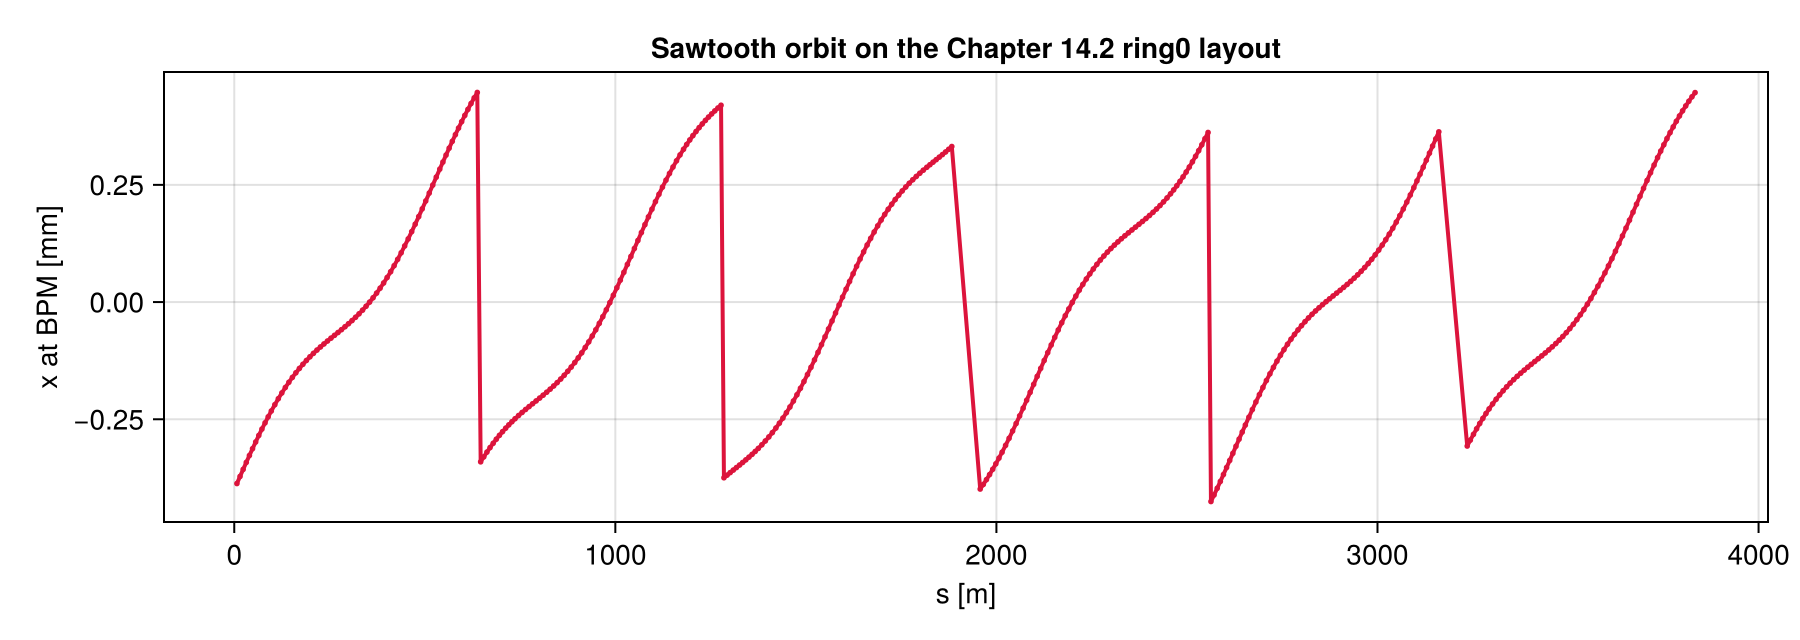

In [23]:
fig = Figure(size=(900, 320))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Sawtooth orbit on the Chapter 14.2 ring0 layout")
lines!(ax, bpm_s, 1e3 .* x_sawtooth; color=:crimson, linewidth=2)
scatter!(ax, bpm_s, 1e3 .* x_sawtooth; color=:crimson, markersize=4)
fig


### 14.2.2 Tapering

Tapering corrects the sawtooth effect by changing magnet strengths according to the local energy around the ring. The idea is different from orbit correction with correctors: tapering changes the lattice magnets themselves so their effective focusing and bending strengths match the local beam energy.

A SciBmad implementation would need a careful element-by-element model of the local energy profile and the corresponding rescaling of magnet strengths. That is still something to study before we put it into this notebook. For now, we continue with the alternative method: correct the measured horizontal orbit using horizontal correctors.


### 14.2.3 Correcting the Sawtooth Orbit with Horizontal Correctors

Now use the BPM readings as the data to correct and the horizontal corrector strengths as variables. Since the sawtooth is horizontal, we only use `CH` correctors and only fit the horizontal BPM readings.

The optimizer solves a regularized least-squares problem:

$$
R k \approx -x_{BPM}
$$

where `R` is the response matrix, `k` is the vector of horizontal corrector kicks, and `x_BPM` is the sawtooth orbit measured at BPMs.

After the solve, the optimized horizontal kicks and corrected BPM orbit are written to `chapter14_sawtooth_ring_after.jl`.


In [24]:
computed_solution = chapter14_optimize_horizontal_correctors(
    bpm_s,
    ch_s,
    x_sawtooth;
    circumference=ring0_layout.circumference,
)

optimized_ring = (
    layout = ring0_layout,
    ch_kicks = computed_solution.kicks,
    x_bpm = computed_solution.corrected_x,
)

optimized_ring_path = chapter14_notebook_file(
    "lattices", "chapter_14", "chapter14_sawtooth_ring_after.jl"
)
chapter14_write_optimized_ring(optimized_ring_path, optimized_ring)

solution = (
    kicks = optimized_ring.ch_kicks,
    corrected_x = optimized_ring.x_bpm,
    response = computed_solution.response,
)

x_corrected = solution.corrected_x

@printf("Corrected horizontal BPM rms: %.4f mm\n", 1e3 * sqrt(mean(abs2, x_corrected)))
@printf("Largest horizontal kick: %.3e rad\n", maximum(abs, solution.kicks))
@printf("Saved optimized ring: %s\n", optimized_ring_path)


Corrected horizontal BPM rms: 0.0425 mm
Largest horizontal kick: 3.617e-04 rad


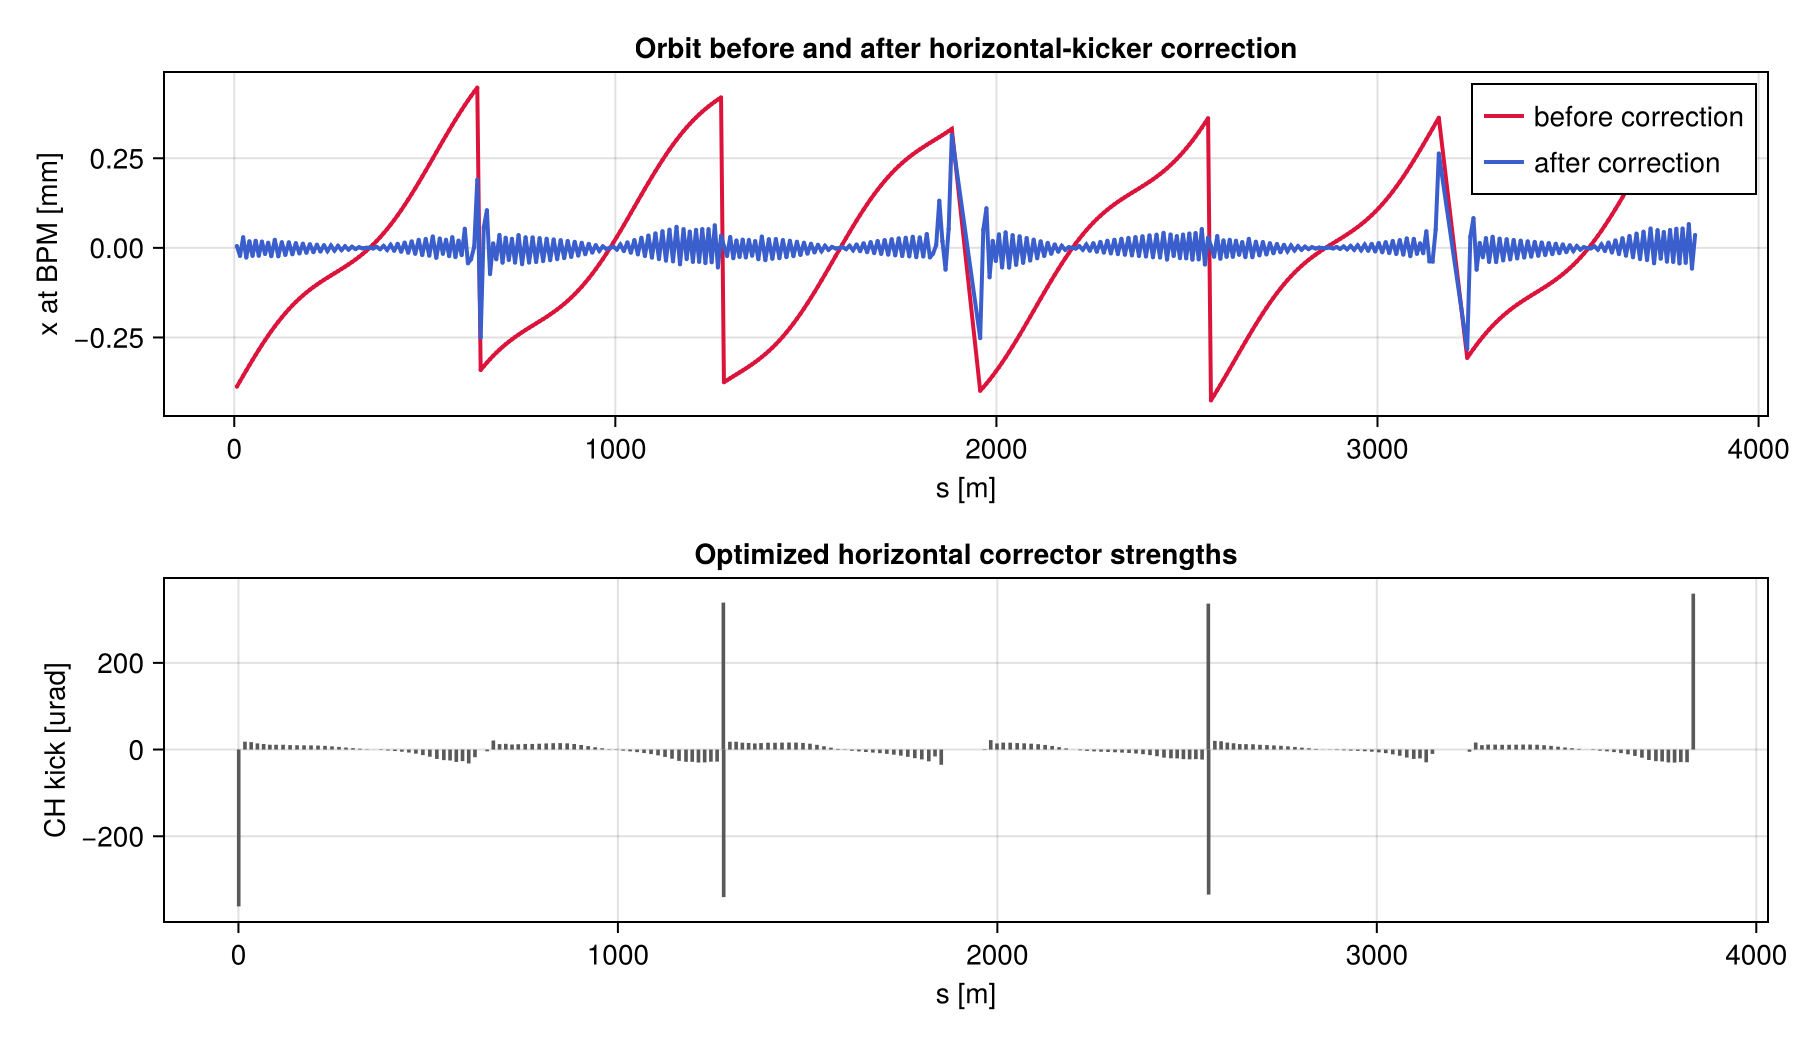

In [25]:
fig = Figure(size=(900, 520))

ax1 = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Orbit before and after horizontal-kicker correction")
lines!(ax1, bpm_s, 1e3 .* x_sawtooth; color=:crimson, linewidth=2, label="before correction")
scatter!(ax1, bpm_s, 1e3 .* x_sawtooth; color=:crimson, markersize=3)
lines!(ax1, bpm_s, 1e3 .* x_corrected; color=:royalblue3, linewidth=2, label="after correction")
scatter!(ax1, bpm_s, 1e3 .* x_corrected; color=:royalblue3, markersize=3)
axislegend(ax1; position=:rt)

ax2 = Axis(fig[2, 1], xlabel="s [m]", ylabel="CH kick [urad]", title="Optimized horizontal corrector strengths")
bar_width = 0.65 * median(diff(ch_s))
barplot!(ax2, ch_s, 1e6 .* solution.kicks; color=:gray35, width=bar_width)

fig


In [ ]:
println("First few optimized horizontal correctors:")
for idx in 1:min(10, length(ch_names_14))
    @printf("  %-10s  %+10.4f urad\n", ch_names_14[idx], 1e6 * solution.kicks[idx])
end
